# Installation [Running this cell required!] <a name="installation"></a>

First, we need to install the necessary libraries. This includes TabPFN itself, as well as other libraries for data manipulation and baseline model comparisons. If you are asked to restart the runtime after installation, please do so.


In [1]:
## Base library Installation
!uv venv
# Installer uv dans l'environnement du notebook
!pip install uv
# Install Baselines for model comparison
!uv pip install catboost xgboost

# Install the datasets library for loading example data
!uv pip install datasets

# Install rich for better and more readable printing
!uv pip install rich

## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install TabPFN extensions for additional functionalities
!uv pip install 'tabpfn-extensions[all]'

# Install tabpfn
!uv pip install tabpfn

Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
? A virtual environment already exists at `.venv`. Do you want to replace it? [y/n] › yes

✔ A virtual environment already exists at `.venv`. Do you want to replace it? · yes
Activate with: source .venv/bin/activate
Using Python 3.12.13 environment at: /usr
Checked 2 packages in 87ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 93ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 87ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 91ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 99ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 91ms


***Note: remember to restart the runtime after the installation.***

# Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.




In [6]:
# Standard Library Imports

# TabPFN and Extensions

try:
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )

    from tabpfn import TabPFNClassifier, TabPFNRegressor
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Other ML Models
from catboost import CatBoostClassifier, CatBoostRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.rule import Rule
from sklearn.compose import make_column_selector, make_column_transformer

# Scikit-Learn: Data & Preprocessing
from sklearn.datasets import fetch_openml, load_breast_cancer

# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

# Backend Selection [Running this cell required!] <a name="backend-selection"></a>


TabPFN can be run in two ways: locally on your machine (if you have a GPU) or by using the TabPFN client, which sends the data to a server for computation.
In your project you would either use the **local** version (which requires a GPU) with:
```python
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

or the **client** API (which uses a remote server):

```python
# Simple import for TabPFN
from tabpfn_client import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

If you select **local** and it's your first time using the model, you'll need to accept the license agreement and log into Hugging Face.
You'll be prompted with instructions on how to do this the first time you fit the model.

For demonstration purposes, the cell below provides an interactive way to switch between local mode and the client:


In [3]:
# Authentication code - No need to read it!

console = Console()

console.print(Panel.fit("[bold magenta]TabPFN Demo: Backend Selection[/bold magenta]"))
console.print("\nThis script can run TabPFN using one of two backends:")
console.print("  [bold]local:[/bold] Uses a local GPU (NVIDIA). Requires CUDA.")
console.print(
    "  [bold]client:[/bold] Uses the TabPFN API. Requires an internet connection and a free account."
)

backend = None
while backend is None:
  console.print(
      "\n[bold]Choose your backend[/bold]: - If no text box is shown, restart the cell.",
  )
  user_input = input("Enter 'local' or 'client' and press return:")
  if user_input not in ["local", "client"]:
    continue
  backend = user_input

console.print(
    f"\n✅ You have selected the '[bold green]{backend}[/bold green]' backend."
)

console.print(Rule(f"[bold]Setting up [cyan]{backend}[/cyan] backend[/bold]"))

if backend == "local":
    console.print("Attempting local backend setup...")
    import torch

    if not torch.cuda.is_available():
        console.print(
            "[bold red]Error:[/bold red] GPU device not found. For fast training, please enable GPU.",
            style="red",
        )
        console.print(
            "In Colab: Go to [bold]Runtime -> Change runtime type -> Hardware accelerator -> GPU.[/bold]",
            style="yellow",
        )
        raise SystemError("GPU device not found.")
    console.print("[bold green]✅ GPU is available.[/bold green]")

    # --- Prior Labs Authentication ---
    console.print(Rule("[bold]Prior Labs Authentication[/bold]"))
    console.print(
        "\nTabPFN model weights require a free [bold]Prior Labs account[/bold] and "
        "acceptance of the non-commercial license.\n"
    )

    import os
    import getpass

    tabpfn_token = None

    # 1. Try Colab secret TABPFN_TOKEN
    try:
        from google.colab import userdata
        tabpfn_token = userdata.get("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Colab secrets.[/bold green]")
    except Exception:
        pass

    # 2. If no token found, prompt the user
    if not tabpfn_token:
        console.print(
            Panel(
                "To get your access token:\n\n"
                "  1. Go to [link=https://ux.priorlabs.ai]ux.priorlabs.ai[/link] and sign up / log in\n"
                "  2. Accept the license at [link=https://ux.priorlabs.ai/account/licenses]ux.priorlabs.ai/account/licenses[/link]\n"
                "  3. Copy your Access Token from [link=https://ux.priorlabs.ai/account]ux.priorlabs.ai/account[/link]\n\n"
                "[bold yellow]Tip:[/bold yellow] Save the token as a Colab secret named "
                "[bold cyan]TABPFN_TOKEN[/bold cyan] to skip this step next time.",
                title="[bold]🔑 Prior Labs Access Token required",
                border_style="blue",
            )
        )
        while not tabpfn_token:
            token_input = getpass.getpass("Paste your TABPFN_TOKEN and press Enter: ")
            if token_input.strip():
                tabpfn_token = token_input.strip()
                os.environ["TABPFN_TOKEN"] = tabpfn_token
            else:
                console.print("[red]Token cannot be empty. Please try again.[/red]")

    console.print("")
    console.print("Importing local TabPFN library...")

    from tabpfn import TabPFNClassifier, TabPFNRegressor

    console.print("[bold green]✅ TabPFN (local) imported successfully.[/bold green]")
elif backend == "client":
    console.print("Attempting client backend setup...")
    console.print("Importing TabPFN client library...")
    from tabpfn_client import TabPFNClassifier, TabPFNRegressor, init

    init()
    console.print("[bold green]✅ TabPFN (client) initialized.[/bold green]")


╭────────────────────────────────╮
│ TabPFN Demo: Backend Selection │
╰────────────────────────────────╯

This script can run TabPFN using one of two backends:

local: Uses a local GPU (NVIDIA). Requires CUDA.

client: Uses the TabPFN API. Requires an internet connection and a free account.

Choose your backend: - If no text box is shown, restart the cell.

...

Email:

guillaume.bedouelle@epfl.ch
Password: ··········


Output()

Login successful!

✅ TabPFN (client) initialized.

# Regression with TabPFN <a name="regression"></a>

Next, we'll explore how to use TabPFN for regression tasks. We will use the CPEC Chemical Catalysis Database CatTestHub dataset, where the goal is to predict the reaction rate.

We will measure performance using the [Root Mean Squared Error](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.root_mean_squared_error.html), and again, we will compare TabPFN with other popular regression models.

In [8]:
# Load the dataset

import pandas as pd
import numpy as np

cat_data=pd.read_csv('/content/CPEC Chemical Catalysis Database_CatTestHub_modified.csv',
                       sep=';',               # On précise que le séparateur est le point-virgule
                       encoding='utf-8-sig')


cat_data=cat_data.dropna(axis=1, how='all')
cat_data.dropna(how='all', inplace=True)
column_feat = ['Metal', 'Support', 'Weight loading [%]','Molecular Weight of Active component [g mol-1]',  'Active Site Density [µmol gcat-1]',
    'Dispersion [%]','Weight Hourly Space Velocity [gCH3OH gcat-1 hr-1]','Temperature [K]','Total Pressure [kPa]',
    'Inlet Inert Used','Inert, Inlet Mole fraction [%] ', 'CO, Inlet Mole fraction [%]','CH4, Inlet Mole Fraction [%]','Methanol, Inlet Mole fraction [%]',
    'Inlet P,Methanol [kPa]', 'Inlet Inert Flow Rate [sccm]','Total Inlet Flow Rate [mol/hr]']

# Création du DataFrame features
features = cat_data[column_feat]

# Affichage
display(features.head())



,Metal,Support,Weight loading [%],Molecular Weight of Active component [g mol-1],Active Site Density [µmol gcat-1],Dispersion [%],Weight Hourly Space Velocity [gCH3OH gcat-1 hr-1],Temperature [K],Total Pressure [kPa],Inlet Inert Used,"Inert, Inlet Mole fraction [%]","CO, Inlet Mole fraction [%]","CH4, Inlet Mole Fraction [%]","Methanol, Inlet Mole fraction [%]","Inlet P,Methanol [kPa]",Inlet Inert Flow Rate [sccm],Total Inlet Flow Rate [mol/hr]
0,Platinum,Silica,1.0,195.08,14.7,30.1,13.0,473.0,102.73,Nitrogen,90.01,0.0,0.0,9.99,10.27,60.0,0.18
1,Platinum,Silica,3.1,195.08,14.0,8.5,NaN,473.0,101.33,Helium,89.40,0.0,0.0,10.60,10.74,60.0,0.18
2,Platinum,Silica,3.1,195.08,14.0,8.5,NaN,423.0,101.33,Helium,97.50,0.0,0.0,2.50,2.53,60.0,0.16
3,Platinum,Silica,3.1,195.08,14.0,8.5,NaN,423.0,101.33,Helium,90.10,0.0,0.0,9.90,10.03,60.0,0.18
4,Platinum,Silica,3.1,195.08,14.0,8.5,NaN,448.0,101.33,Helium,97.20,0.0,0.0,2.80,2.84,60.0,0.17


In [9]:
X=features
y=cat_data['Rate [μmol product gcat-1min-1]'].values

In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Train and evaluate the TabPFN regressor
tabpfn_regressor = TabPFNRegressor(random_state=42)
tabpfn_regressor.fit(X_train, y_train)
y_pred = tabpfn_regressor.predict(X_test)

# Calculate the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"TabPFN RMSE: {rmse:.4f}")

tabpfn-v2.5-regressor-v2.5_default.ckpt:   0%|          | 0.00/40.8M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

TabPFN RMSE: 4.0911


### Comparing TabPFN with Other Regressors

Now, let's see how TabPFN's regression performance stacks up against other models using cross-validation.


In [27]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

# Define models
models = [
    ("TabPFN", TabPFNRegressor(random_state=42)),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestRegressor(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBRegressor(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostRegressor(random_state=42, verbose=0),
        ),
    ),
]


In [32]:
# Calculate scores
scoring = "neg_root_mean_squared_error"
n_splits = 68
cv = KFold(n_splits=n_splits, random_state=42, shuffle=True)
scores = {
    name: cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=1, verbose=1)
    for name, model in models
}


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   37.2s
[Parallel(n_jobs=1)]: Done  68 out of  68 | elapsed:   51.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    7.8s
[Parallel(n_jobs=1)]: Done  68 out of  68 | elapsed:   11.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done  68 out of  68 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   19.4s
[Parallel(n_jobs=1)]: Done  68 out of  68 | elapsed:   27.7s finished


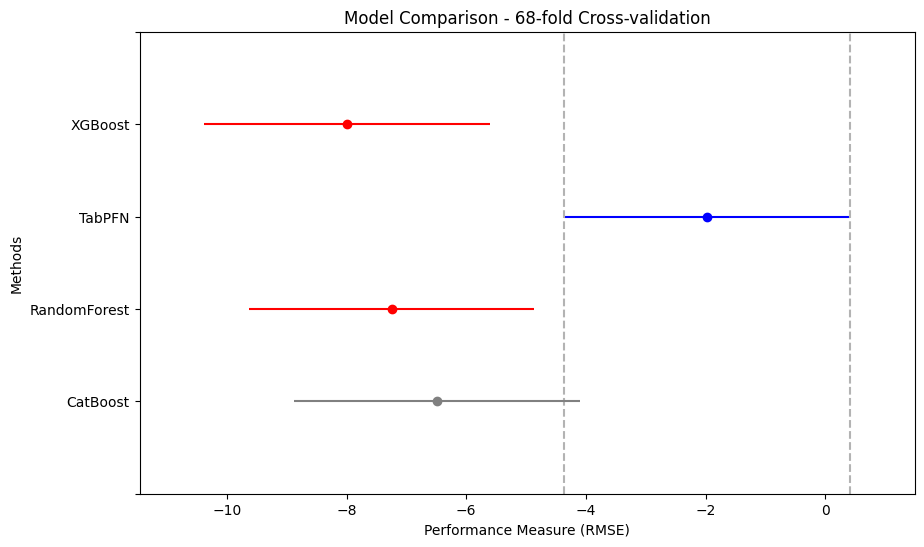

In [36]:
####Visualisation des comparaisons de performance

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# On transforme tes scores (dictionnaire de listes) en DataFrame "long"
data = []
for model_name, model_scores in scores.items():
    for s in model_scores:
        data.append({"Model": model_name, "Score": s})

df_long = pd.DataFrame(data)

# 1. Calculer le test de Tukey HSD
# endog = les scores, groups = les noms des modèles
tukey = pairwise_tukeyhsd(endog=df_long['Score'], groups=df_long['Model'], alpha=0.05)

# 2. Créer le graphique
#comparison_name : le nom du modèle que tu veux mettre en bleu (le "meilleur")
fig = tukey.plot_simultaneous(comparison_name="TabPFN", figsize=(10, 6))

# 3. Personnalisation esthétique
ax = fig.get_axes()[0] # Récupère l'objet axe pour le modifier
ax.set_title(f"Model Comparison - {n_splits}-fold Cross-validation")
ax.set_xlabel("Performance Measure (RMSE)")
ax.set_ylabel("Methods")

plt.show()